In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

In [12]:
(X_train, y_train), (X_test, y_test)=tf.keras.datasets.mnist.load_data()
print(f'Training data shape: {X_train.shape}')
print(f'Test data shape: {X_test.shape}')


Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


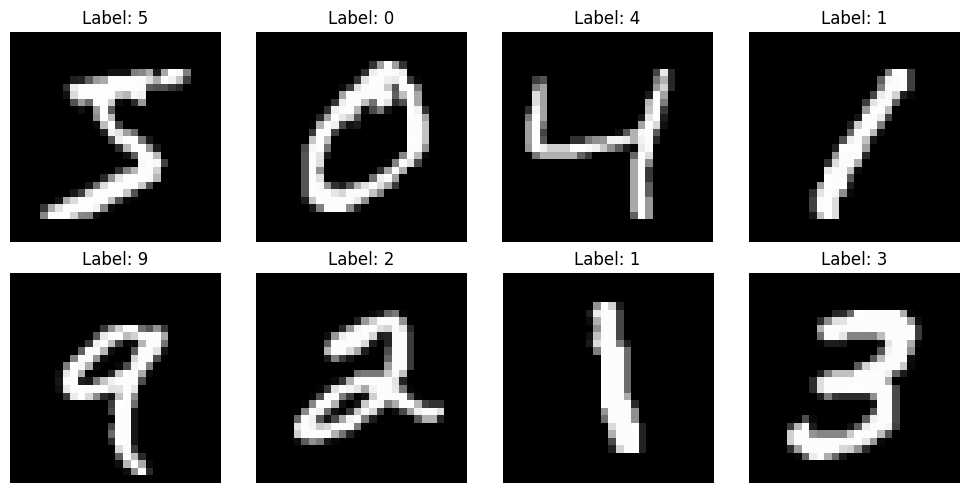

In [17]:

# Plot first 8 training images
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set(title=f'Label: {y_train[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [18]:
# Normalize to 0-1 range
x_train = X_train / 255.0
x_test = X_test / 255.0

# Flatten for dense network (28*28=784 features)
X_train_flat = x_train.reshape(60000, -1)
X_test_flat = x_test.reshape(10000, -1)

print(f'Flattened training shape: {X_train_flat.shape}')


Flattened training shape: (60000, 784)


In [19]:
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])
model.summary()

c:\Users\Professor\miniconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# Train for 5 epochs (adjust as needed)
history = model.fit(
    x_train, y_train,  # Use original shapes (model handles flatten)
    epochs=5,
    validation_data=(x_test, y_test),
    verbose=1
)

Epoch 1/5


c:\Users\Professor\miniconda3\Lib\site-packages\keras\src\backend\tensorflow\nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9149 - loss: 0.2939 - val_accuracy: 0.9601 - val_loss: 0.1349
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9581 - loss: 0.1403 - val_accuracy: 0.9691 - val_loss: 0.1020
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9676 - loss: 0.1053 - val_accuracy: 0.9751 - val_loss: 0.0851
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9741 - loss: 0.0861 - val_accuracy: 0.9772 - val_loss: 0.0745
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9774 - loss: 0.0738 - val_accuracy: 0.9778 - val_loss: 0.0711


Test accuracy: 0.9778
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
Predicted: 7, Actual: 7


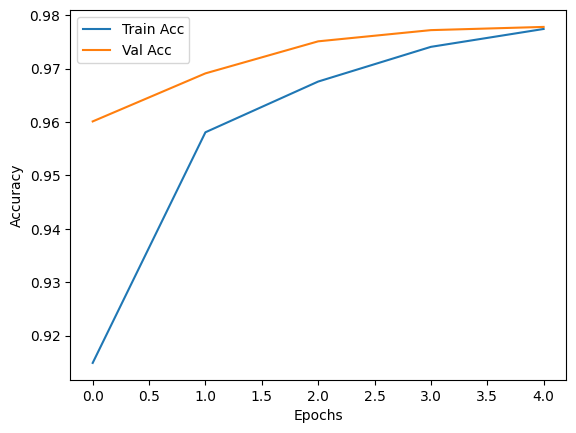

In [21]:
# Final evaluation
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test accuracy: {test_acc:.4f}')

# Predict on first test image
probabilities = model.predict(x_test[:1])
predicted_digit = np.argmax(probabilities)
print(f'Predicted: {predicted_digit}, Actual: {y_test[0]}')

# Plot training history
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [23]:
model.save("D:\\Github\\Artificial-Intelligence-Labs\\MNIST Digit Classifier\\model\\mnist.keras") 